# Shor's Algorithm – the *quantum* part

> **Heads-up.** The original notebook used `from qiskit.algorithms import Shor`, but the high-level **`Shor` class has been removed** from Qiskit. (It was deprecated in Qiskit 0.22 and dropped when `qiskit.algorithms` itself was migrated out of the SDK.)
>
> In this updated version we **build the period-finding circuit by hand** for the textbook example `N = 15, a = 7`. The classical post-processing (continued fractions → period → `gcd`) is then a few lines of plain Python – exactly what the `QX11` notebook walked through.

The four pieces of Shor's quantum sub-routine:

1. A counting register in superposition.
2. A work register initialised to `|1⟩`.
3. Repeated **controlled modular multiplication** by `a` (`7` here) on the work register, controlled by each counting qubit.
4. An **inverse QFT** on the counting register, followed by a measurement.

The peak positions of the resulting histogram encode the period `r`. Once we have `r`, classical post-processing recovers the factors of `N`.

### Required packages

```bash
pip install qiskit qiskit-aer matplotlib pylatexenc
```

In [1]:
from fractions import Fraction
import math

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

%matplotlib inline

### Step 2 – Build the period-finding circuit

The circuit has two registers:

- **`n_count` counting qubits** – they will hold the QFT estimate of the phase `s/r`.
- **4 work qubits** – store the value of `7^x mod 15` (which fits in 4 bits because `15 < 2^4`).

The recipe:

1. Hadamard every counting qubit (uniform superposition over all `x`).
2. Initialise the work register to `|1⟩`.
3. For each counting qubit `j`, apply a **controlled-`U^(2^j)`** on the work register, where `U |y⟩ = |a·y mod 15⟩`.
4. Apply the **inverse QFT** to the counting register.
5. Measure the counting register.

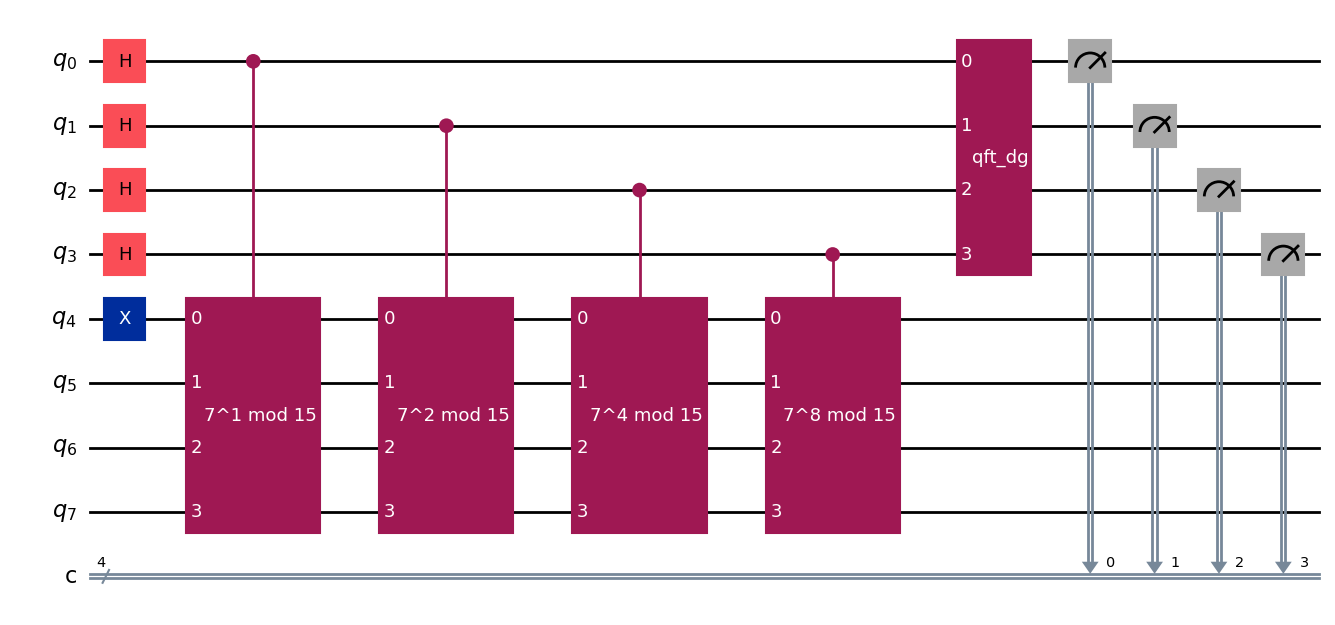

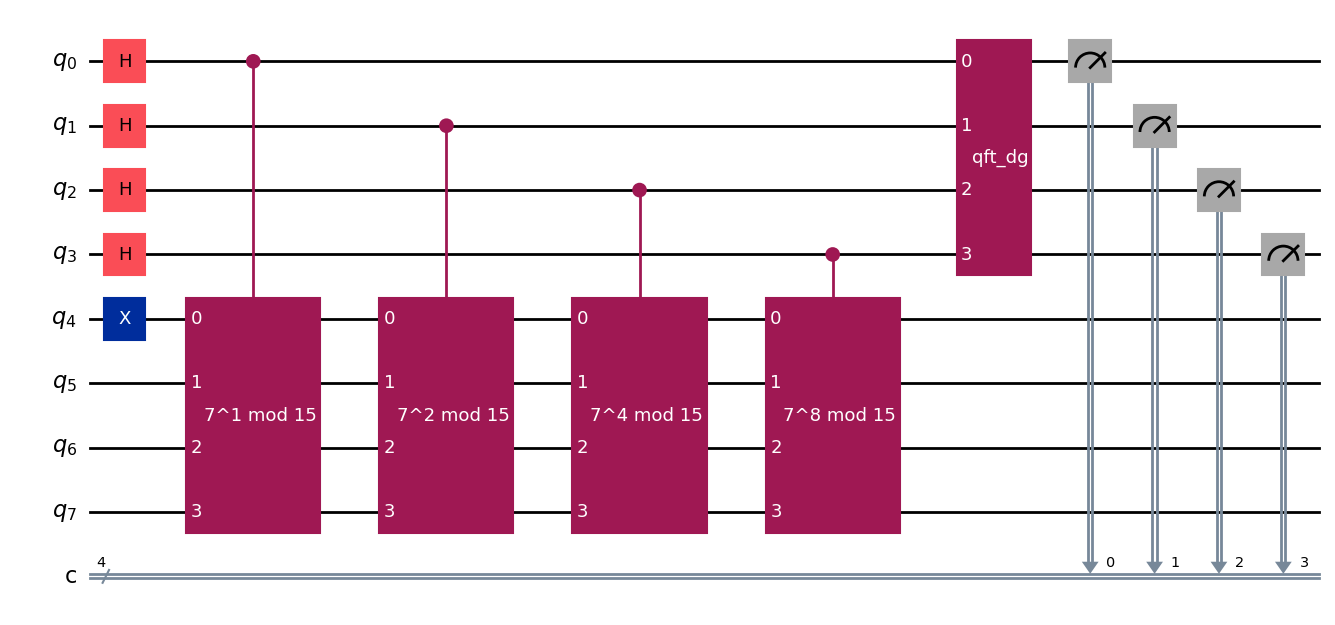

In [2]:
def c_amod15(a, power):
    """Controlled-(a^power mod 15) on 4 work qubits.

    Specialised to N = 15. The "magic" permutations come from the standard
    Qiskit textbook chapter on Shor's algorithm – they implement the
    multiplication-by-`a` mod 15 as a sequence of SWAPs and X gates.
    """
    if a not in (2, 4, 7, 8, 11, 13):
        raise ValueError("a must be coprime to 15 and one of 2, 4, 7, 8, 11, 13")

    U = QuantumCircuit(4)
    for _ in range(power):
        if a in (2, 13):
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        if a in (7, 8):
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        if a in (4, 11):
            U.swap(1, 3); U.swap(0, 2)
        if a in (7, 11, 13):
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    return U.control()


def shor_period_finding_circuit(a, n_count=4):
    """Build the period-finding circuit for `a^x mod 15`."""
    qc = QuantumCircuit(n_count + 4, n_count)

    for q in range(n_count):
        qc.h(q)
    qc.x(n_count)

    for j in range(n_count):
        qc.append(c_amod15(a, 2 ** j), [j] + list(range(n_count, n_count + 4)))

    # Inverse QFT on the counting register.
    # `QFTGate` is the modern replacement for the deprecated `QFT` class.
    iqft = QFTGate(num_qubits=n_count).inverse()
    qc.append(iqft, range(n_count))

    qc.measure(range(n_count), range(n_count))
    return qc


N, a = 15, 7
n_count = 4
circuit = shor_period_finding_circuit(a, n_count=n_count)
circuit.draw(output="mpl", fold=-1)

### Step 3 – Run the circuit and look at the histogram

Run on the local simulator with 2048 shots. The histogram should have **four sharp peaks** spaced equally across the 4-bit register – the signature that the period is `r = 4`.

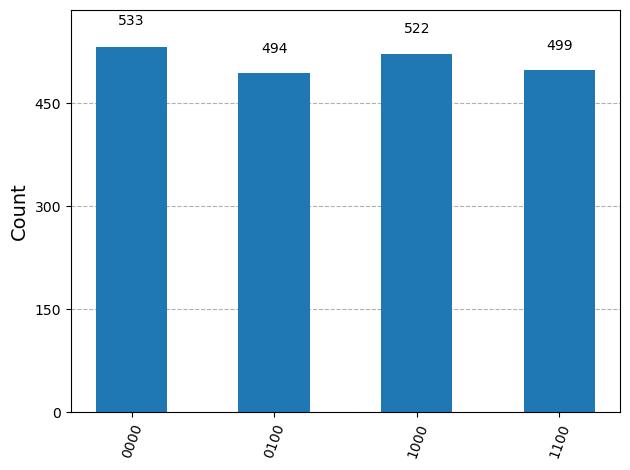

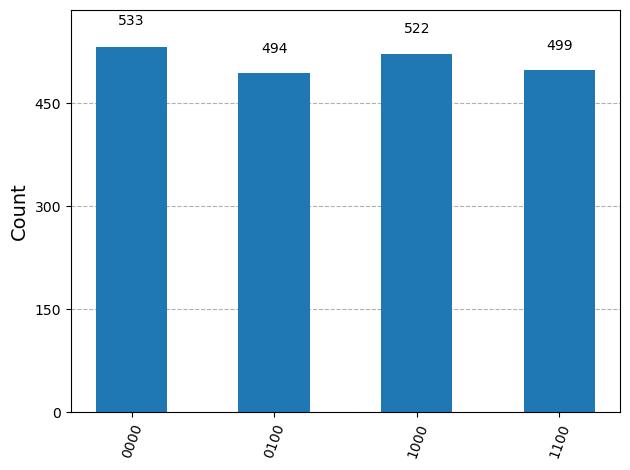

In [3]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
counts = simulator.run(compiled, shots=2048).result().get_counts()
plot_histogram(counts)

### Step 4 – From measurement outcomes to factors

Each measurement is an integer between `0` and `2^n - 1` that encodes a fraction `s/r` (where `r` is the period we are looking for). We use **continued fractions** (`fractions.Fraction.limit_denominator`) to recover `r`, and then plug it into the classical post-processing from `QX11`.

You should see one of the four "good" peaks at `0`, `4`, `8`, `12` (in 4-bit binary: `0000`, `0100`, `1000`, `1100`), giving period `r = 4` and factors `3` and `5`.

In [4]:
# Convert the measurement outcomes (which encode `s/r` in `n_count` bits)
# into candidate periods using continued fractions, then derive the factors.

def factors_from_period(N, a, r):
    """Return non-trivial factors of N from period r, if possible."""
    if r % 2 != 0:
        return None
    x = pow(a, r // 2, N)
    if x == N - 1:
        return None
    p, q = math.gcd(x + 1, N), math.gcd(x - 1, N)
    if 1 < p < N and 1 < q < N:
        return sorted({p, q})
    return None


print(f"Trying to factor N = {N}  with base a = {a}\n")
candidate_periods = set()
for bitstring, count in sorted(counts.items(), key=lambda kv: -kv[1]):
    measured = int(bitstring, 2)
    phase = measured / (2 ** n_count)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    print(f"  bits={bitstring}  measured={measured:>3}  phase={phase:.4f}  r≈{r}  ({count} shots)")
    if r > 0:
        candidate_periods.add(r)

print("\nCandidate periods:", sorted(candidate_periods))
for r in sorted(candidate_periods):
    factors = factors_from_period(N, a, r)
    if factors is not None:
        print(f"  period r={r}  →  factors of {N}: {factors}")
        break
else:
    print("  No usable period found – pick a different base 'a' and try again.")

Trying to factor N = 15  with base a = 7

  bits=0000  measured=  0  phase=0.0000  r≈1  (533 shots)
  bits=1000  measured=  8  phase=0.5000  r≈2  (522 shots)
  bits=1100  measured= 12  phase=0.7500  r≈4  (499 shots)
  bits=0100  measured=  4  phase=0.2500  r≈4  (494 shots)

Candidate periods: [1, 2, 4]
  period r=4  →  factors of 15: [3, 5]
